# ASR error rates

Transcribe news and ecommerce clips from SLURP and from the recorded set, then compare open-source and paid models on word error rate, character error rate, latency, and cost.

## Setup

Import libraries, load API keys from `.env`, and prepare the text normalizer used for WER and CER.


In [1]:
import asyncio
import gc
import io
import json
import os
import time
from concurrent.futures import ThreadPoolExecutor

%matplotlib inline
import jiwer
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import soundfile as sf
import torch
from datasets import Audio, load_dataset
from dotenv import load_dotenv
from tqdm.auto import tqdm
from whisper.normalizers import EnglishTextNormalizer

from src.utils.models import ASR_MODELS, Models

load_dotenv()
normalize = EnglishTextNormalizer()


/home/rakesh/Downloads/ShortTok/2.NoiseCancellation/NoiseCancellation/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Settings

Clip groups, noise names, API concurrency, hourly prices, and the model order used in the charts.


In [2]:
DATASET = "qmeeus/slurp"
SLURP_CSV = "audio/open_source/slurp.csv"
INTENTS = {
    "news": {"news_query"},
    "ecommerce": {"lists_createoradd", "lists_query", "lists_remove", "takeaway_order", "takeaway_query"},
}
GROUPS = [
    "slurp_news", "slurp_ecommerce",
    "recorded_clean_news", "recorded_clean_ecommerce",
    "recorded_noisy_news", "recorded_noisy_ecommerce",
]
NOISES = ("Claps & Cheers", "Traffic & Wind", "Retail Ambient Noise")
API_LIMIT = {"deepgram": 4, "elevenlabs": 4, "assemblyai": 4, "speechmatics": 2}  ## concurrency limits
USD_PER_HOUR = {
    "whisper-small": 0, "whisper-large": 0, "parakeet": 0,
    "deepgram": 0.0043 * 60, "elevenlabs": 0.22, "assemblyai": 0.15, "speechmatics": 0.23,
}  ## batch-rates
OPEN_SOURCE = {"whisper-small", "whisper-large", "parakeet"}
CHART_MODELS = ["whisper-small", "whisper-large", "parakeet", "deepgram", "elevenlabs", "assemblyai", "speechmatics"]


## Loaders

Read a wav into a mono float array, and load the SLURP clips plus the recorded clean and noisy clips.


In [3]:
def read_wav(source):
    if isinstance(source, (bytes, bytearray)):
        source = io.BytesIO(source)
    array, sampling_rate = sf.read(source, dtype="float32")
    array = np.asarray(array, np.float32)
    if array.ndim > 1:
        array = array.mean(axis=1)
    return int(sampling_rate), array


def load_slurp(per_group=50, split="test"):
    if os.path.exists(SLURP_CSV):
        rows = pd.read_csv(SLURP_CSV)
        samples = [{"group": row.group, "intent": row.intent, "text": row.text, "audio_path": row.audio, "audio": read_wav(row.audio)} for row in rows.itertuples(index=False)]
        print({group: int((rows.group == group).sum()) for group in INTENTS}, "total", len(samples))
        return samples

    wanted = {name: group for group, names in INTENTS.items() for name in names}
    buckets = {group: [] for group in INTENTS}
    stream = load_dataset(DATASET, split=split, streaming=True).cast_column("audio", Audio(decode=False))
    labels = stream.features["intent"]
    for row in stream:
        name = labels.int2str(row["intent"]) if isinstance(row["intent"], int) else row["intent"]
        group = wanted.get(name)
        if group is None or len(buckets[group]) >= per_group:
            continue
        buckets[group].append({"group": group, "intent": name, "text": row["sentence"], "audio": read_wav(row["audio"]["bytes"])})
        if all(len(items) == per_group for items in buckets.values()):
            break

    samples = [item for items in buckets.values() for item in items]
    os.makedirs(os.path.dirname(SLURP_CSV), exist_ok=True)
    records = []
    folder = os.path.dirname(SLURP_CSV)
    for sample in samples:
        sampling_rate, array = sample["audio"]
        safe = " ".join(sample["text"].replace("/", " ").split()).rstrip(".")[:120].rstrip() or "audio"
        path, count = f"{folder}/{safe}.wav", 2
        while os.path.exists(path):
            path, count = f"{folder}/{safe} {count}.wav", count + 1
        sf.write(path, array, sampling_rate)
        sample["audio_path"] = path
        records.append({"group": sample["group"], "intent": sample["intent"], "text": sample["text"], "audio": path})
    pd.DataFrame(records).to_csv(SLURP_CSV, index=False)
    print({group: len(items) for group, items in buckets.items()}, "total", len(samples))
    return samples


def load_recorded(kind):
    directory = f"audio/recorded/{kind}"
    loaded = []
    for name in sorted(os.listdir(directory)):
        if not name.endswith(".wav"):
            continue
        text = os.path.splitext(name)[0]
        for noise in NOISES:
            marker = f"_{noise}_"
            if marker in text:
                text = text.split(marker)[0]
                break
        lowered = text.lower()
        topic = "news" if "news" in lowered or "washington" in lowered or lowered.startswith("what's up") else "ecommerce"
        path = f"{directory}/{name}"
        loaded.append({"group": f"recorded_{kind}_{topic}", "text": text, "audio_path": path, "audio": read_wav(path)})
    return loaded


## Clips

Build the full clip list and print how many clips are in each group, with the median duration in seconds.


In [4]:
all_samples = [{**sample, "group": f"slurp_{sample['group']}"} for sample in load_slurp()]
all_samples += load_recorded("clean") + load_recorded("noisy")
print({group: sum(sample["group"] == group for sample in all_samples) for group in GROUPS})
seconds = pd.Series([len(sample["audio"][1]) / sample["audio"][0] for sample in all_samples], index=[sample["group"] for sample in all_samples])
print(seconds.groupby(level=0).median().round(2).reindex(GROUPS))
all_samples[:2]


{'news': 50, 'ecommerce': 50} total 100
{'slurp_news': 50, 'slurp_ecommerce': 50, 'recorded_clean_news': 9, 'recorded_clean_ecommerce': 6, 'recorded_noisy_news': 108, 'recorded_noisy_ecommerce': 72}
slurp_news                  2.94
slurp_ecommerce             2.37
recorded_clean_news         2.76
recorded_clean_ecommerce    2.55
recorded_noisy_news         2.76
recorded_noisy_ecommerce    2.55
dtype: float64


[{'group': 'slurp_news',
  'intent': 'news_query',
  'text': 'what is the exchange rate of us dollar to pound sterling',
  'audio_path': 'audio/open_source/what is the exchange rate of us dollar to pound sterling.wav',
  'audio': (16000,
   array([ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00, ...,
           0.0000000e+00, -3.0517578e-05,  0.0000000e+00], dtype=float32))},
 {'group': 'slurp_news',
  'intent': 'news_query',
  'text': 'what is the exchange rate of us dollar to pound sterling',
  'audio_path': 'audio/open_source/what is the exchange rate of us dollar to pound sterling 2.wav',
  'audio': (16000,
   array([ 0.0000000e+00, -6.1035156e-05,  6.1035156e-05, ...,
           9.2773438e-02,  1.2808228e-01,  3.0517578e-05], dtype=float32))}]

## Scoring

Word and character error rate for one model on one group, after English text normalization.


In [5]:
def score(samples, hypotheses, group):
    chosen = [(normalize(sample["text"]), normalize(hypothesis)) for sample, hypothesis in zip(samples, hypotheses) if sample["group"] == group]
    references, guesses = zip(*chosen)
    return jiwer.wer(list(references), list(guesses)), jiwer.cer(list(references), list(guesses)), len(chosen)


## Transcription

Local model transcription, the four paid speech APIs, and the table of WER, CER, and latency.


In [6]:
def transcribe_local(models, samples):
    transcriptions = {}
    for name, asr in zip(models.names, models.asrs):
        hypotheses, elapsed = [], []
        for sample in tqdm(samples, desc=name):
            start = time.perf_counter()
            hypotheses.append(models.transcribe(sample["audio"], asr))
            elapsed.append((time.perf_counter() - start) * 1000)
        transcriptions[name] = (hypotheses, elapsed)
    return transcriptions


def wav_bytes(audio):
    sampling_rate, samples = audio
    buffer = io.BytesIO()
    sf.write(buffer, np.asarray(samples, np.float32), int(sampling_rate), format="WAV")
    return buffer.getvalue()


async def _transcribe_api(samples, call, name):
    limit = asyncio.Semaphore(API_LIMIT.get(name, 1))
    results = [None] * len(samples)
    progress = tqdm(total=len(samples), desc=name)

    async def one(index, sample):
        async with limit:
            start = time.perf_counter()
            text = await asyncio.to_thread(call, wav_bytes(sample["audio"]))
            results[index] = (text, (time.perf_counter() - start) * 1000)
            progress.update(1)

    await asyncio.gather(*(one(index, sample) for index, sample in enumerate(samples)))
    progress.close()
    hypotheses, elapsed = zip(*results)
    return list(hypotheses), list(elapsed)


def transcribe_api(samples, call, name):
    task = _transcribe_api(samples, call, name)
    try:
        asyncio.get_running_loop()
    except RuntimeError:
        return asyncio.run(task)
    with ThreadPoolExecutor(1) as pool:
        return pool.submit(asyncio.run, task).result()


def post(url, headers, timeout=60, **kwargs):
    response = requests.post(url, headers=headers, timeout=timeout, **kwargs)
    response.raise_for_status()
    return response


def deepgram(wav):
    response = post(
        "https://api.deepgram.com/v1/listen",
        {"Authorization": f"Token {os.environ['DEEPGRAM_API_KEY']}", "Content-Type": "audio/wav"},
        params={"model": "nova-3", "language": "en"},
        data=wav,
    )
    return response.json()["results"]["channels"][0]["alternatives"][0]["transcript"]


def elevenlabs(wav):
    response = post(
        "https://api.elevenlabs.io/v1/speech-to-text",
        {"xi-api-key": os.environ["ELEVENLABS_API_KEY"]},
        files={"file": ("clip.wav", wav, "audio/wav")},
        data={"model_id": "scribe_v2", "language_code": "en"},
    )
    return response.json().get("text") or ""


def assemblyai(wav):
    response = post(
        "https://sync.assemblyai.com/v1/transcribe",
        {"Authorization": os.environ["ASSEMBLYAI_API_KEY"], "X-AAI-Model": "universal-3-5-pro"},
        files={"audio": ("clip.wav", wav, "audio/wav")},
    )
    return response.json().get("text") or ""


def speechmatics(wav):
    response = post(
        os.environ.get("SPEECHMATICS_URL", "https://eu1.asr.api.speechmatics.com/v2/jobs"),
        {"Authorization": f"Bearer {os.environ['SPEECHMATICS_API_KEY']}"},
        timeout=90,
        params={"wait": 60, "format": "txt"},
        files={"data_file": ("clip.wav", wav, "audio/wav")},
        data={"config": json.dumps({"type": "transcription", "transcription_config": {"language": "en", "model": "enhanced"}})},
    )
    body = response.json()
    if body.get("status") != "done":
        raise RuntimeError(body.get("status"))
    return body.get("txt") or ""


def evaluate(samples, transcriptions):
    rows = []
    for name, (hypotheses, elapsed) in transcriptions.items():
        for group in GROUPS:
            wer, cer, count = score(samples, hypotheses, group)
            latency = np.mean([ms for sample, ms in zip(samples, elapsed) if sample["group"] == group])
            rows.append({"model": name, "group": group, "wer (%)": round(wer * 100, 1), "cer (%)": round(cer * 100, 1), "latency (ms)": round(latency)})
    return pd.DataFrame(rows)


## Run

Transcribe every clip, then write `results/predictions.csv`, `results/metrics.csv`, and `results/overall_metrics.csv`.


In [7]:
os.makedirs("results", exist_ok=True)
frames, predictions = [], []

def keep(transcriptions):
    for name, (hypotheses, elapsed) in transcriptions.items():
        for index, (sample, hypothesis, ms) in enumerate(zip(all_samples, hypotheses, elapsed)):
            predictions.append({"model": name, "index": index, "group": sample["group"], "audio_path": sample["audio_path"], "text": sample["text"], "prediction": hypothesis, "latency_ms": round(ms, 1)})
        frames.append(evaluate(all_samples, {name: (hypotheses, elapsed)}))

asr_models = None
for name in ASR_MODELS:
    if asr_models is not None:
        del asr_models
        gc.collect()
        torch.cuda.empty_cache()
    asr_models = Models(name)
    keep(transcribe_local(asr_models, all_samples))
load_dotenv(override=True)
api_models = {"deepgram": deepgram, "elevenlabs": elevenlabs, "assemblyai": assemblyai, "speechmatics": speechmatics}
missing = [key for key in ("DEEPGRAM_API_KEY", "ELEVENLABS_API_KEY", "ASSEMBLYAI_API_KEY", "SPEECHMATICS_API_KEY") if not os.environ.get(key)]
if missing:
    raise RuntimeError(f"Set {', '.join(missing)} in .env")
for name, call in api_models.items():
    keep({name: transcribe_api(all_samples, call, name)})

metrics = pd.concat(frames, ignore_index=True)
hours = np.mean([len(sample["audio"][1]) / sample["audio"][0] for sample in all_samples]) / 3600
overall = metrics.groupby("model", sort=False)[["wer (%)", "cer (%)", "latency (ms)"]].median().round(1).add_prefix("median ").reset_index()
overall.insert(1, "source", ["open-source" if name in OPEN_SOURCE else "paid" for name in overall["model"]])
overall["cost ($/hr)"] = overall["model"].map(USD_PER_HOUR)
overall.to_csv("results/overall_metrics.csv", index=False)
metrics["avg cost ($)"] = metrics["model"].map({name: round(hours * rate, 6) for name, rate in USD_PER_HOUR.items()})
metrics.loc[metrics.groupby("model", sort=False).cumcount().gt(0), "avg cost ($)"] = pd.NA
pd.DataFrame(predictions).to_csv("results/predictions.csv", index=False)
metrics.to_csv("results/metrics.csv", index=False)
metrics


Loading weights: 100%|██████████| 287/287 [00:00<00:00, 3817.37it/s]


asr_freq: whisper-small 16000


whisper-small:   0%|          | 0/295 [00:00<?, ?it/s][transformers] Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
[transformers] Passing `generation_config` together with generation-related arguments=({'suppress_tokens', 'begin_suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
Loading weights: 100%|██████████| 1259/1259 [00:00<00:00, 4064.55it/s]


asr_freq: whisper-large 16000


Loading weights: 100%|██████████| 723/723 [00:00<00:00, 2892.50it/s]


asr_freq: parakeet 16000


parakeet:   0%|          | 0/295 [00:00<?, ?it/s]/home/rakesh/Downloads/ShortTok/2.NoiseCancellation/NoiseCancellation/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=400) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
parakeet:   0%|          | 1/295 [00:01<05:16,  1.08s/it]/home/rakesh/Downloads/ShortTok/2.NoiseCancellation/NoiseCancellation/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=410) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(
/home/rakesh/Downloads/ShortTok/2.NoiseCancellation/NoiseCancellation/.venv/lib/python3.12/site-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_len

,model,group,wer (%),cer (%),latency (ms),avg cost ($)
0,whisper-small,slurp_news,22.2,12.9,118,0.000000
1,whisper-small,slurp_ecommerce,26.6,13.7,70,NaN
2,whisper-small,recorded_clean_news,0.0,0.0,78,NaN
3,whisper-small,recorded_clean_ecommerce,11.9,6.8,83,NaN
4,whisper-small,recorded_noisy_news,19.4,11.5,79,NaN
5,whisper-small,recorded_noisy_ecommerce,24.0,14.0,80,NaN
6,whisper-large,slurp_news,10.2,6.6,608,0.000000
7,whisper-large,slurp_ecommerce,12.7,6.9,548,NaN
8,whisper-large,recorded_clean_news,0.0,0.0,621,NaN
9,whisper-large,recorded_clean_ecommerce,0.0,0.0,616,NaN


## Charts

Horizontal bar charts of WER, CER, and latency by group, saved under `results/`.


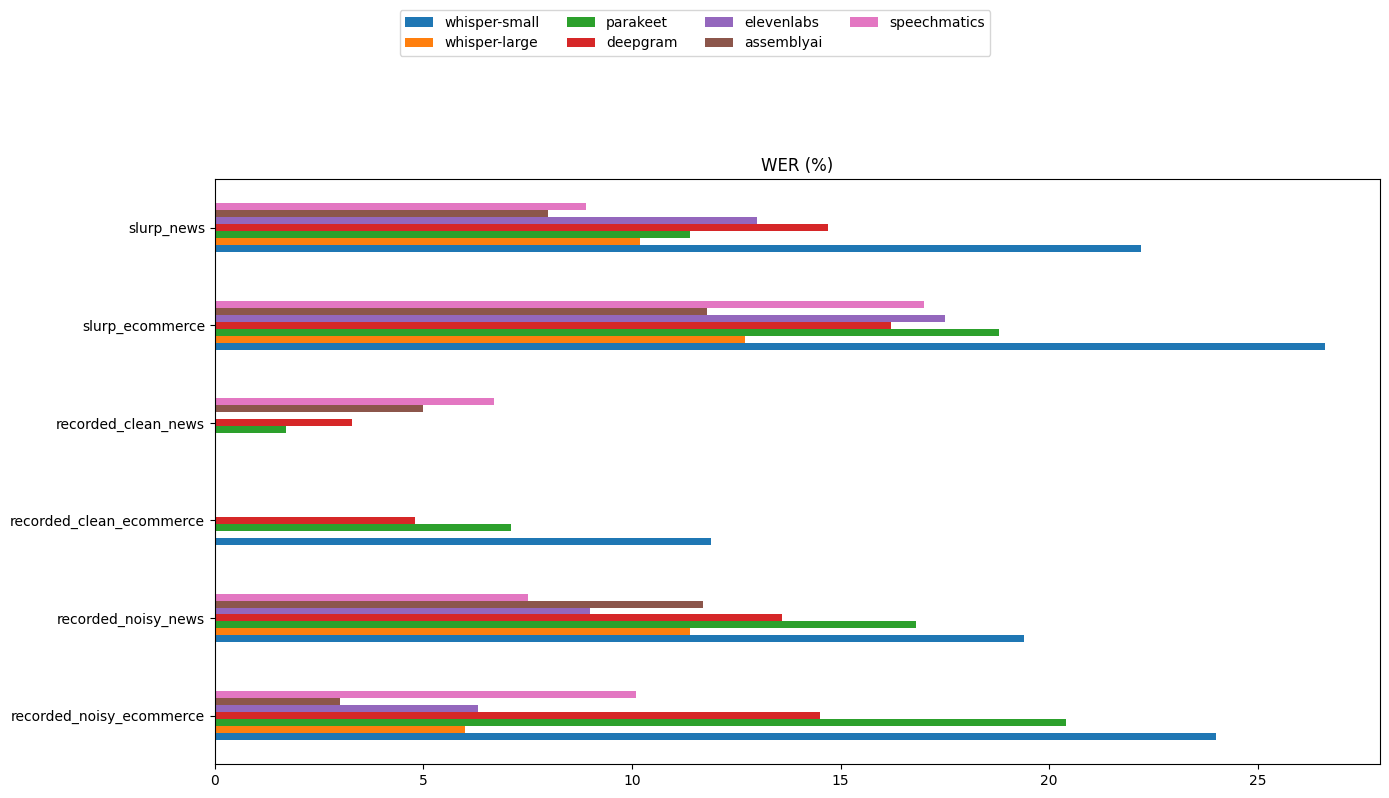

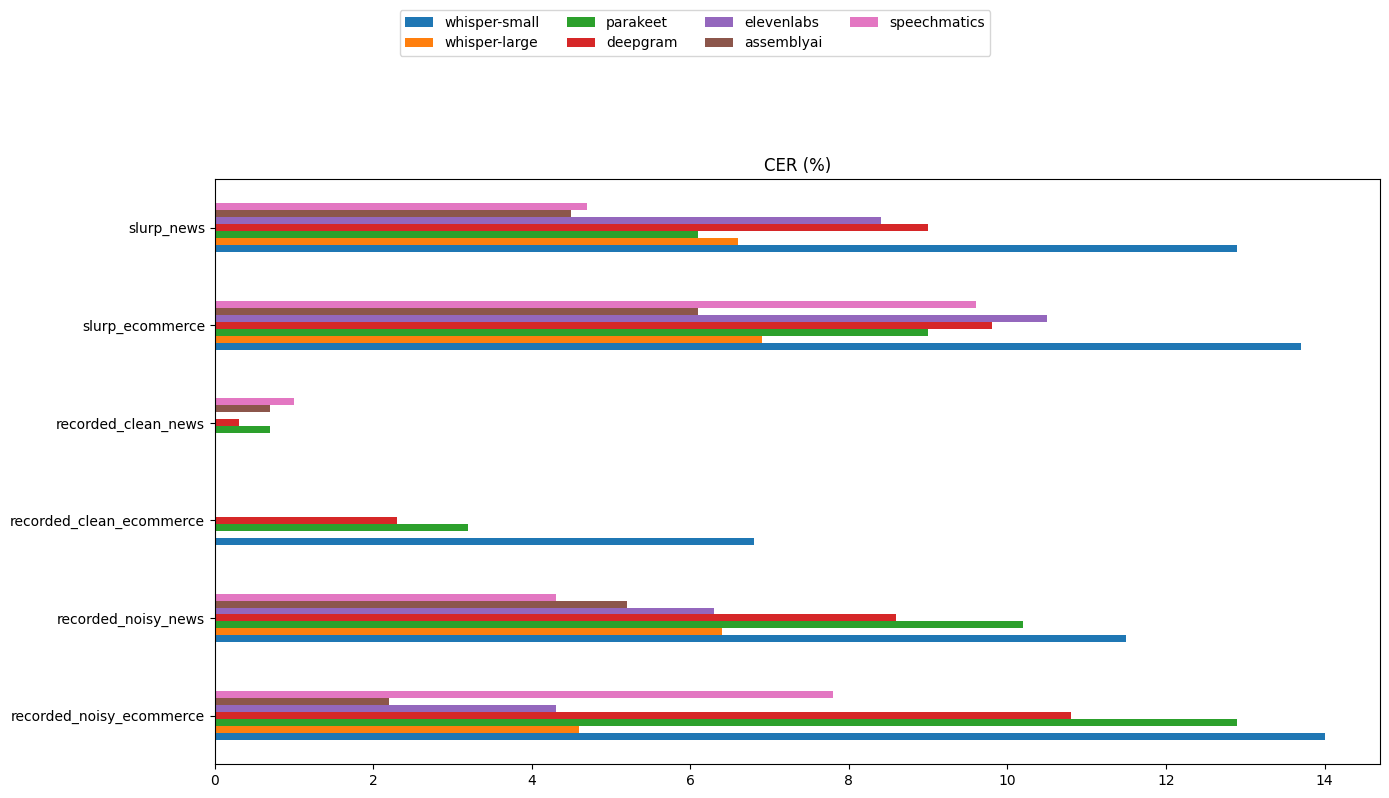

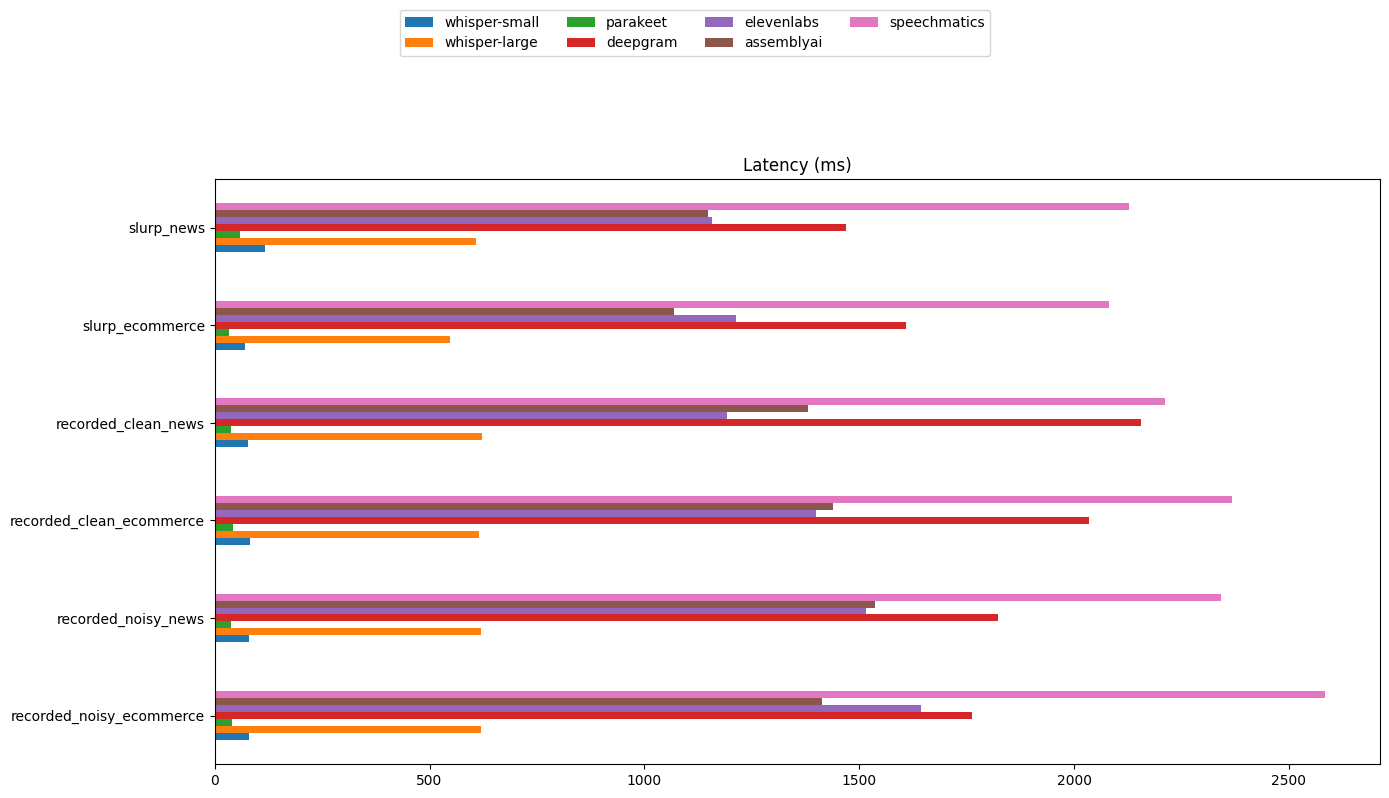

In [8]:
models = [name for name in CHART_MODELS if name in set(metrics["model"])]
for column, title in zip(["wer (%)", "cer (%)", "latency (ms)"], ["WER (%)", "CER (%)", "Latency (ms)"]):
    ax = metrics.pivot(index="group", columns="model", values=column).reindex(GROUPS[::-1])[models].plot.barh(figsize=(14, 8), legend=False)
    ax.set_title(title)
    ax.set_ylabel("")
    handles, labels = ax.get_legend_handles_labels()
    ax.figure.legend(handles, labels, loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.0))
    ax.figure.tight_layout()
    ax.figure.subplots_adjust(top=0.78)
    ax.figure.savefig(f"results/{column.split()[0]}.png", bbox_inches="tight")
plt.show()
